# CelebA Deblurring Experiment with DPS + Anomaly-Heatmap (KLIP)

This notebook demonstrates:

1. **DPS deblurring** on CelebA-HQ 256×256 images using a pre-trained DDPM  
   (`google/ddpm-celebahq-256`).
2. **Anomaly heatmap** generation: measurement-update signals accumulated  
   over a diffusion timestep window are used to localise image artifacts.
3. **AUC evaluation** of the heatmap against binary masks.
4. **Synthetic artifact generation**: a scar/wound patch is composited onto  
   clean faces and paired with a pixel-accurate mask for evaluation.

---

## Configuration — set your paths here


In [2]:
# ============================================================
# USER CONFIGURATION — edit these paths before running
# ============================================================

# Directory / filename (without extension) of the test image(s).
# Single-image example:
INPUT_IMAGE_PATH = "image copy 44"  # path without .png extension

# Directory that contains test images for the batch AUC evaluation.
# Images are expected as <name>.png  +  <name>_mask.png pairs.
TEST_IMAGE_DIR = "./test_artifact_added"

# List of image stem names (no extension) to evaluate AUC over.
# Leave empty [] to auto-discover all *_mask.png in TEST_IMAGE_DIR.
EVAL_IMAGE_STEMS = [
    "00002", "00015", "00017", "00029",
    "00038", "00043", "00052", "00057",
    "00002_1", "00015_1", "00017_1", "00029_1",
    "00038_1", "00043_1", "00052_1", "00057_1",
    "00002_2", "00015_2", "00017_2", "00029_2",
    "00038_2", "00043_2", "00052_2", "00057_2",
]

# Path to the artifact image used for synthetic scar generation.
ARTIFACT_IMAGE_PATH = "./pngegg.png"

# Output directory for synthetic artifact images + masks.
ARTIFACT_OUT_DIR = "./test_artifact_added"

# GPU device string (e.g. "cuda:0", "cuda:6", or "cpu")
DEVICE_STR = "cuda:0"

# ── Diffusion / DPS parameters ──────────────────────────────────────────────
NUM_INFERENCE_STEPS = 100   # diffusion reverse steps
NUM_SAMPLES         = 8     # parallel noisy samples per image
DPS_SCALE           = 0.3   # data-consistency step size ζ
SIGMA_Y             = 1.0   # measurement noise std (used in DPS gradient)
BASE_SEED           = 44    # per-sample seed offset for reproducibility

# Blur operator parameters (ksize × ksize Gaussian)
BLUR_KSIZE_TRUE     = 21    # ksize used to generate the blurry measurement
BLUR_SIGMA_TRUE     = 9.0   # sigma used to generate the blurry measurement
BLUR_SIGMA_MODEL    = 9.0   # sigma assumed by the DPS solver (mismatch → harder task)

# ── Heatmap / anomaly detection parameters ──────────────────────────────────
START_WINDOW = 65   # first timestep index (0-indexed) to accumulate signal
STOP_WINDOW  = 85   # last  timestep index (exclusive)


## 1. Imports and Reproducibility

In [3]:
import os
import random
import math
import time

import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import roc_curve, auc

from diffusers import DDPMPipeline

# Deterministic CUDA ops (required for reproducibility)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True)


def set_seed(seed: int) -> None:
    """Set all RNG seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False


SEED = 0
os.environ["PYTHONHASHSEED"] = str(SEED)
set_seed(SEED)
print(f"Seed set to {SEED}.")


/home/akheirandish3/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seed set to 0.


## 2. Load Pretrained DDPM

In [4]:
model_id = "google/ddpm-celebahq-256"
pipe = DDPMPipeline.from_pretrained(
    model_id, torch_dtype=torch.float32, use_safetensors=False
)
pipe = pipe.to(DEVICE_STR)
pipe.unet.eval()

device = (
    pipe._execution_device
    if hasattr(pipe, "_execution_device")
    else next(pipe.unet.parameters()).device
)
dtype = next(pipe.unet.parameters()).dtype
print(f"Model loaded on device={device}, dtype={dtype}")


Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00, 18.32it/s]


Model loaded on device=cuda:0, dtype=torch.float32


## 3. Blur Operator and Image Utilities

In [5]:
# ── Gaussian blur kernel ────────────────────────────────────────────────────
def _make_gaussian_kernel(ksize: int, sigma: float, device, dtype):
    """Return a (1,1,ksize,ksize) normalised Gaussian kernel."""
    ax = torch.arange(ksize, device=device, dtype=dtype) - (ksize - 1) / 2
    xx, yy = torch.meshgrid(ax, ax, indexing="xy")
    k = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return (k / k.sum())[None, None]


class BlurOp(nn.Module):
    """
    Depthwise Gaussian blur with circular padding.
    Symmetric kernel ⟹ H^T = H.
    """

    def __init__(self, ksize: int = 21, sigma: float = 3.0):
        super().__init__()
        self.ksize, self.sigma = ksize, sigma
        self._cache: dict = {}

    def _kernel(self, x: torch.Tensor) -> torch.Tensor:
        key = (x.device, x.dtype)
        if key not in self._cache:
            self._cache[key] = _make_gaussian_kernel(
                self.ksize, self.sigma, x.device, x.dtype
            )
        return self._cache[key]

    def H(self, x: torch.Tensor) -> torch.Tensor:
        C = x.shape[1]
        k = self._kernel(x)
        pad = k.shape[-1] // 2
        return F.conv2d(
            F.pad(x, (pad, pad, pad, pad), mode="circular"),
            k.repeat(C, 1, 1, 1),
            groups=C,
        )

    def Ht(self, x: torch.Tensor) -> torch.Tensor:
        """Adjoint (equals H for symmetric Gaussian kernels)."""
        return self.H(x)


# ── PIL ↔ tensor helpers ────────────────────────────────────────────────────
def pil_to_model_tensor(
    img_pil: Image.Image,
    device,
    dtype,
    size: tuple[int, int] | None = None,
) -> torch.Tensor:
    """Load a PIL image into a (1,3,H,W) tensor in model range [-1, 1]."""
    if size is not None:
        img_pil = img_pil.resize((size[1], size[0]), resample=Image.BICUBIC)
    arr = np.array(img_pil.convert("RGB"), dtype=np.float32) / 255.0
    x = torch.from_numpy(arr).permute(2, 0, 1)[None].to(device=device, dtype=dtype)
    return x * 2.0 - 1.0


def tensor_to_pil(x: torch.Tensor, index: int = 0) -> Image.Image:
    """Convert a (B,3,H,W) tensor in [-1,1] to a PIL image."""
    x = (x.clamp(-1, 1) + 1) / 2
    arr = (x[index].permute(1, 2, 0).detach().cpu().numpy() * 255.0).round().astype(np.uint8)
    return Image.fromarray(arr)


## 4. DPS Core — Measurement Update Step

In [6]:
def _dps_update_xt(
    xt: torch.Tensor,
    t_idx: int,
    eps_t: torch.Tensor,
    alphas_cumprod: torch.Tensor,
    H,
    Ht,
    y: torch.Tensor,
    sigma_y: float,
    dps_scale: float = 1.0,
    match_prior_norm: bool = True,
) -> torch.Tensor:
    """
    Apply one DPS data-consistency gradient step.

    Returns the updated x_t (the measurement update delta is x_t_new - x_t_old).

    Parameters
    ----------
    xt            : current noisy estimate  (B,C,H,W)
    t_idx         : integer timestep index into alphas_cumprod
    eps_t         : UNet noise prediction
    alphas_cumprod: scheduler alphas_cumprod tensor
    H, Ht         : forward operator and its adjoint
    y             : measurement  (B,C,H,W)
    sigma_y       : measurement noise std
    dps_scale     : step-size multiplier ζ
    match_prior_norm : if True, scale ζ to match the prior-score norm
    """
    a_bar = alphas_cumprod[t_idx].to(xt.device, xt.dtype).clamp(1e-6, 1.0)
    sqrt_a_bar = a_bar.sqrt().view(1, 1, 1, 1)
    sigma_t = (1.0 - a_bar).sqrt().view(1, 1, 1, 1)

    # Tweedie x0 estimate
    x0_hat = (xt - sigma_t * eps_t) / sqrt_a_bar

    # Likelihood gradient w.r.t. x_t
    resid = y - H(x0_hat)
    grad_x0 = Ht(resid) / (sigma_y**2 + 1e-12)
    grad_xt = grad_x0 / sqrt_a_bar

    if match_prior_norm:
        prior_norm = (eps_t / (sigma_t + 1e-12)).reshape(xt.shape[0], -1).norm(dim=1).mean()
        like_norm  = grad_xt.reshape(xt.shape[0], -1).norm(dim=1).mean()
        zeta = dps_scale * (prior_norm.detach() / (like_norm.detach() + 1e-12))
    else:
        resid_norm = resid.reshape(xt.shape[0], -1).norm(dim=1).mean()
        zeta = dps_scale / (resid_norm.detach() + 1e-12)

    return xt + zeta * grad_xt


## 5. DPS Sampling with Stored Measurement Updates

> **Key modification from original PaDIS**: at each diffusion timestep the  
> measurement-update delta `Δx_t = x_t_after_DPS − x_t_before_DPS` is stored.  
> These updates are later used to build the anomaly heatmap.


In [7]:
@torch.no_grad()
def dps_deblur_sample(
    pipe,
    y_blurry: torch.Tensor,
    blur_op: BlurOp,
    num_inference_steps: int = NUM_INFERENCE_STEPS,
    sigma_y: float = SIGMA_Y,
    dps_scale: float = DPS_SCALE,
    match_prior_norm: bool = False,
    generator: torch.Generator | None = None,
) -> tuple:
    """
    Run DPS reverse diffusion for deblurring.

    Returns
    -------
    images          : list containing the final x0 tensor  (B,3,H,W)
    alphas_cumprod  : scheduler alphas_cumprod tensor
    measurement_list: list[Tensor(B,3,H,W)] — per-step measurement updates (stored for KLIP)
    image_list      : list[Tensor(B,3,H,W)] — x_t after each scheduler step
    diffusion_list  : list[Tensor(B,3,H,W)] — per-step diffusion deltas
    """
    device = (
        pipe._execution_device
        if hasattr(pipe, "_execution_device")
        else next(pipe.unet.parameters()).device
    )
    dtype  = next(pipe.unet.parameters()).dtype
    unet, scheduler = pipe.unet, pipe.scheduler

    B, C, H, W = y_blurry.shape
    y_blurry = y_blurry.to(device=device, dtype=dtype)

    # Initialise x_T with per-sample deterministic seeds for reproducibility
    xt = torch.empty((B, C, H, W), device=device, dtype=dtype)
    for i in range(B):
        g = torch.Generator(device=device).manual_seed(BASE_SEED + i)
        xt[i] = torch.randn((C, H, W), device=device, dtype=dtype, generator=g)

    measurement_list, diffusion_list, image_list = [], [], []
    scheduler.set_timesteps(num_inference_steps, device=device)

    for t in scheduler.timesteps:
        eps = unet(xt, t).sample
        t_idx = int(t.item())

        # ── DPS measurement update ──────────────────────────────────────────
        x_before = xt.clone()
        xt = _dps_update_xt(
            xt, t_idx, eps, scheduler.alphas_cumprod,
            blur_op.H, blur_op.Ht, y_blurry,
            sigma_y, dps_scale, match_prior_norm,
        )
        measurement_list.append(xt - x_before)   # stored for KLIP / heatmap

        # ── Scheduler reverse step (diffusion update) ───────────────────────
        x_before = xt.clone()
        xt = scheduler.step(eps, t, xt, generator=generator).prev_sample
        diffusion_list.append(xt - x_before)
        image_list.append(xt.clone())

    # Final Tweedie x0 estimate at t = 0
    a_bar0 = scheduler.alphas_cumprod[0].to(device=device, dtype=dtype)
    eps0 = unet(xt, torch.tensor(0, device=device)).sample
    x0 = (xt - (1.0 - a_bar0).sqrt().view(1,1,1,1) * eps0) / a_bar0.sqrt().view(1,1,1,1)
    x0 = x0.clamp(-1, 1)

    return [x0], scheduler.alphas_cumprod, measurement_list, image_list, diffusion_list


## 6. Run DPS on a Single Image

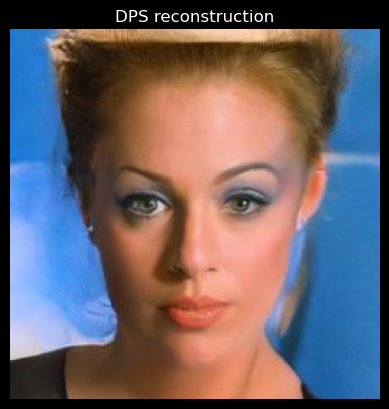

Saved: blurry_measurement.png


In [8]:
def run_dps_on_image(
    file_path: str,
    num_samples: int = NUM_SAMPLES,
    blur_sigma_model: float = BLUR_SIGMA_MODEL,
) -> tuple:
    """
    Load <file_path>.png, create a blurry measurement, and run DPS.

    Parameters
    ----------
    file_path        : path stem (without .png) to the input image
    num_samples      : number of parallel samples (batch size)
    blur_sigma_model : sigma assumed by the solver (may differ from true sigma)

    Returns
    -------
    Same outputs as dps_deblur_sample().
    """
    clean_pil = Image.open(f"{file_path}.png").convert("RGB")
    x0_11 = pil_to_model_tensor(clean_pil, device=device, dtype=dtype, size=(256, 256))

    # ── Build blurry measurement with true blur ─────────────────────────────
    blur_true = BlurOp(ksize=BLUR_KSIZE_TRUE, sigma=BLUR_SIGMA_TRUE)
    gen = torch.Generator(device=device).manual_seed(SEED)
    y_blurry = blur_true.H(x0_11)
    noise = torch.randn(y_blurry.shape, generator=gen,
                        device=y_blurry.device, dtype=y_blurry.dtype)
    y_blurry = (y_blurry + 0.0 * noise).clamp(-1, 1)  # sigma_y=0 → noiseless measurement

    y_blurry_batch = y_blurry.expand(num_samples, -1, -1, -1).contiguous()
    tensor_to_pil(y_blurry).save("blurry_measurement.png")

    # ── DPS with (possibly mismatched) model blur ───────────────────────────
    blur_model = BlurOp(ksize=BLUR_KSIZE_TRUE, sigma=blur_sigma_model)
    gen.manual_seed(SEED)
    return dps_deblur_sample(
        pipe=pipe,
        y_blurry=y_blurry_batch,
        blur_op=blur_model,
        num_inference_steps=NUM_INFERENCE_STEPS,
        sigma_y=SIGMA_Y,
        dps_scale=DPS_SCALE,
        match_prior_norm=False,
        generator=gen,
    )


# ── Run ─────────────────────────────────────────────────────────────────────
images, alphas_cumprod, measurement_list, image_list, diffusion_list = run_dps_on_image(
    INPUT_IMAGE_PATH, num_samples=NUM_SAMPLES
)

plt.imshow(tensor_to_pil(images[0]))
plt.axis("off")
plt.title("DPS reconstruction")
plt.show()
print("Saved: blurry_measurement.png")


## 7. Anomaly Heatmap from Stored Measurement Updates

The heatmap is computed as the normalised squared measurement-update signal  
summed over timesteps in `[START_WINDOW, STOP_WINDOW)`.  
Dividing by `sqrt(β_t)` re-scales updates to be comparable across timesteps.


In [9]:
def measurement_updates_to_heatmap(
    measurement_list: list,
    scheduler,
    start_window: int = START_WINDOW,
    stop_window: int = STOP_WINDOW,
) -> np.ndarray:
    """
    Aggregate stored measurement updates into a (256,256) anomaly heatmap.

    Parameters
    ----------
    measurement_list : list of (B,3,H,W) tensors, one per diffusion step
    scheduler        : DDPM scheduler (for betas / timesteps)
    start_window     : first step index to include (0-indexed)
    stop_window      : last step index to include (exclusive)

    Returns
    -------
    heatmap : float32 array  (256,256)
    """
    unet, sched = pipe.unet, pipe.scheduler
    time_steps  = sched.timesteps.cpu().numpy().astype(int)
    gt = np.sqrt(sched.betas[time_steps].cpu().numpy()).reshape(-1, 1, 1, 1, 1, 1)

    # Stack updates: shape (T, B, 3, 256, 256) → mean over B → (T, 3, 256, 256)
    stack = np.zeros((len(measurement_list), 3, 256, 256), dtype=np.float32)
    for idx, upd in enumerate(measurement_list):
        stack[idx] = upd.mean(dim=0, keepdim=True).cpu().squeeze(0).numpy()

    # Reshape to (T, 3, 256//ps, ps, 256//ps, ps) with patch_size=1
    patch_size = 1
    stack_r = stack.reshape(len(measurement_list), 3,
                             256 // patch_size, patch_size,
                             256 // patch_size, patch_size)

    metric = (stack_r / gt) ** 2
    heatmap = metric[start_window:stop_window].sum(axis=(0, 1, 3, 5))  # (256,256)
    return heatmap.astype(np.float32)


heatmap = measurement_updates_to_heatmap(measurement_list, pipe.scheduler)
print(f"Heatmap shape: {heatmap.shape}, min={heatmap.min():.4f}, max={heatmap.max():.4f}")


Heatmap shape: (256, 256), min=0.0000, max=0.0561


## 8. Visualisation — Heatmap Overlay on Original Image

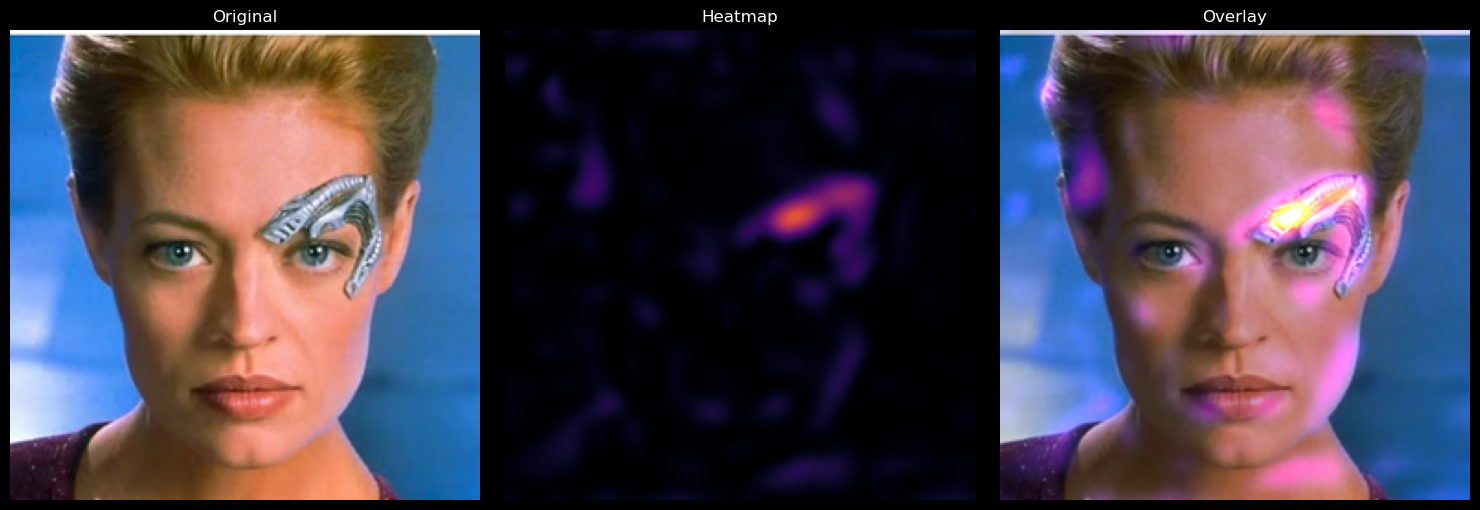

In [10]:
def make_overlay(
    background: np.ndarray,
    heatmap: np.ndarray,
    alpha_bg: float = 0.8,
    alpha_hm: float = 1.2,
    percentile_low: float = 20,
) -> np.ndarray:
    """
    Blend a colourised heatmap over a background image.

    Parameters
    ----------
    background    : (H,W,3) float or uint8 image
    heatmap       : (H,W) float anomaly scores
    alpha_bg      : weight for background
    alpha_hm      : weight for heatmap overlay
    percentile_low: heatmap values below this percentile are clipped to 0

    Returns
    -------
    overlay : (H,W,3) float in [0,1]
    """
    # Normalise heatmap
    hm = heatmap.copy().astype(np.float32)
    hm = (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)
    threshold = np.percentile(hm, percentile_low)
    hm = np.clip((hm - threshold) / (1 - threshold + 1e-8), 0, 1)

    # Normalise background to [0,255]
    bg = background.astype(np.float32)
    bg = (bg - bg.min()) / (bg.max() - bg.min() + 1e-8) * 255

    # Resize heatmap to match background
    bg_h, bg_w = bg.shape[:2]
    hm_pil = Image.fromarray((hm * 255).astype(np.uint8)).resize((bg_w, bg_h), Image.BILINEAR)
    hm_resized = np.array(hm_pil) / 255.0

    hm_colored = plt.get_cmap("inferno")(hm_resized)[..., :3] * 255
    bg_rgb = np.stack([bg] * 3, axis=-1) if bg.ndim == 2 else bg

    overlay = np.clip(alpha_bg * bg_rgb + alpha_hm * hm_colored, 0, 255) / 255.0
    return overlay


# Load original image for display
clean_pil = Image.open(f"{INPUT_IMAGE_PATH}.png").convert("RGB")
img_arr = np.array(clean_pil, dtype=np.float32) / 255.0

overlay = make_overlay(img_arr, heatmap)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_arr); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(heatmap, cmap="inferno", vmin=0.001, vmax=0.09)
axes[1].set_title("Heatmap"); axes[1].axis("off")
axes[2].imshow(overlay); axes[2].set_title("Overlay"); axes[2].axis("off")
plt.tight_layout()
plt.show()


## 9. AUC Evaluation over a Dataset

In [11]:
def evaluate_auc_on_dataset(
    image_stems: list[str],
    image_dir: str = TEST_IMAGE_DIR,
    num_samples: int = NUM_SAMPLES,
    blur_sigma_model: float = BLUR_SIGMA_MODEL,
    start_window: int = START_WINDOW,
    stop_window: int = STOP_WINDOW,
) -> list[float]:
    """
    Compute per-image AUC scores for a list of image stems.

    Expects:  <image_dir>/<stem>.png   (image)
              <image_dir>/<stem>_mask.png  (binary ground-truth mask)

    Returns list of AUC values (one per image processed).
    """
    auc_list = []

    for stem in image_stems:
        img_path  = os.path.join(image_dir, f"{stem}.png")
        mask_path = os.path.join(image_dir, f"{stem}_mask.png")

        if not os.path.exists(img_path):
            print(f"[SKIP] Image not found: {img_path}")
            continue
        if not os.path.exists(mask_path):
            print(f"[SKIP] Mask not found: {mask_path}")
            continue

        # Run DPS
        file_stem = os.path.join(image_dir, stem)
        _, _, meas_list, _, _ = run_dps_on_image(
            file_stem, num_samples=num_samples, blur_sigma_model=blur_sigma_model
        )

        # Build heatmap
        hm = measurement_updates_to_heatmap(meas_list, pipe.scheduler,
                                             start_window, stop_window)

        # Load mask
        mask_np = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)
        labels  = (mask_np > 127).flatten().astype(int)
        scores  = hm.flatten()

        fpr, tpr, _ = roc_curve(labels, scores)
        roc_auc = auc(fpr, tpr)
        auc_list.append(roc_auc)
        print(f"  {stem}: AUC = {roc_auc:.4f}")

    print(f"\nAverage AUC over {len(auc_list)} images: {np.mean(auc_list):.4f}")
    return auc_list


auc_results = evaluate_auc_on_dataset(
    image_stems=[os.path.splitext(s)[0]
                 for s in EVAL_IMAGE_STEMS],
    image_dir=TEST_IMAGE_DIR,
    num_samples=NUM_SAMPLES,
    blur_sigma_model=BLUR_SIGMA_MODEL,
    start_window=START_WINDOW,
    stop_window=STOP_WINDOW,
)


  00002: AUC = 0.9984
  00015: AUC = 0.9920
  00017: AUC = 0.9913
  00029: AUC = 0.9614
  00038: AUC = 0.9208
  00043: AUC = 0.9909
  00052: AUC = 0.9987
  00057: AUC = 0.9985
  00002_1: AUC = 0.8762
  00015_1: AUC = 0.8978
  00017_1: AUC = 0.7817
  00029_1: AUC = 0.4456
  00038_1: AUC = 0.9073
  00043_1: AUC = 0.8529
  00052_1: AUC = 0.9945
  00057_1: AUC = 0.8676
  00002_2: AUC = 0.9316
  00015_2: AUC = 0.8830
  00017_2: AUC = 0.8987
  00029_2: AUC = 0.5715
  00038_2: AUC = 0.8361
  00043_2: AUC = 0.9224
  00052_2: AUC = 0.9835
  00057_2: AUC = 0.9829

Average AUC over 24 images: 0.8952


## 10. Memory-Efficient Streaming Heatmap (optional)

Instead of storing all measurement updates and post-processing them,  
this function accumulates the heatmap *on-the-fly* during the sampling loop —
saving GPU memory at the cost of not having the full update list available afterwards.


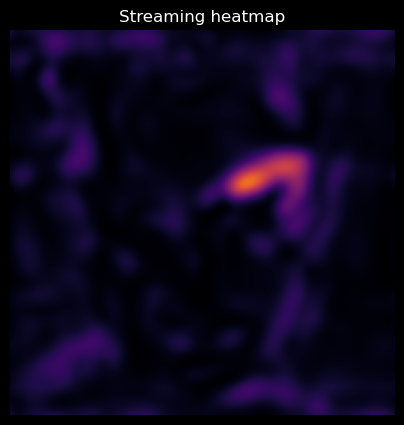

In [12]:
@torch.no_grad()
def dps_deblur_heatmap_streaming(
    pipe,
    y_blurry: torch.Tensor,
    blur_op: BlurOp,
    num_inference_steps: int = NUM_INFERENCE_STEPS,
    sigma_y: float = SIGMA_Y,
    dps_scale: float = DPS_SCALE,
    match_prior_norm: bool = False,
    generator: torch.Generator | None = None,
    start_window: int = START_WINDOW,
    stop_window: int = STOP_WINDOW,
) -> np.ndarray:
    """
    Run DPS and return a (256,256) anomaly heatmap accumulated on-the-fly.
    Does NOT return intermediate states (lower memory usage).
    """
    device = (
        pipe._execution_device
        if hasattr(pipe, "_execution_device")
        else next(pipe.unet.parameters()).device
    )
    dtype  = next(pipe.unet.parameters()).dtype
    unet, scheduler = pipe.unet, pipe.scheduler

    B, C, H, W = y_blurry.shape
    y_blurry = y_blurry.to(device=device, dtype=dtype)

    # Per-sample seeded init
    xt = torch.empty((B, C, H, W), device=device, dtype=dtype)
    for i in range(B):
        g = torch.Generator(device=device).manual_seed(BASE_SEED + i)
        xt[i] = torch.randn((C, H, W), device=device, dtype=dtype, generator=g)

    scheduler.set_timesteps(num_inference_steps, device=device)
    heatmap = torch.zeros((H, W), device=device, dtype=torch.float32)

    for k, t in enumerate(scheduler.timesteps):
        eps = unet(xt, t).sample
        t_int = int(t.item())

        x_before = xt.clone()
        xt = _dps_update_xt(
            xt, t_int, eps, scheduler.alphas_cumprod,
            blur_op.H, blur_op.Ht, y_blurry,
            sigma_y, dps_scale, match_prior_norm,
        )

        # Accumulate heatmap within the window
        if start_window <= k < stop_window:
            beta_t = scheduler.betas[t_int].to(device=device, dtype=torch.float32)
            delta = (xt - x_before).to(torch.float32)
            # sum over batch & channels, mean over batch
            heatmap += (delta / beta_t.sqrt()).pow(2).sum(dim=1).mean(dim=0)

        xt = scheduler.step(eps, t, xt, generator=generator).prev_sample

    return heatmap.cpu().numpy()


# Example usage
gen = torch.Generator(device=device).manual_seed(SEED)
clean_pil = Image.open(f"{INPUT_IMAGE_PATH}.png").convert("RGB")
x0_11 = pil_to_model_tensor(clean_pil, device=device, dtype=dtype, size=(256, 256))
blur_true  = BlurOp(ksize=BLUR_KSIZE_TRUE, sigma=BLUR_SIGMA_TRUE)
blur_model = BlurOp(ksize=BLUR_KSIZE_TRUE, sigma=BLUR_SIGMA_MODEL)
y_blurry = blur_true.H(x0_11).clamp(-1, 1).expand(NUM_SAMPLES, -1, -1, -1).contiguous()

hm_streaming = dps_deblur_heatmap_streaming(
    pipe=pipe,
    y_blurry=y_blurry,
    blur_op=blur_model,
    generator=gen,
)

plt.figure(figsize=(5, 5))
plt.imshow(hm_streaming, cmap="inferno", vmin=0.001, vmax=0.09)
plt.axis("off")
plt.title("Streaming heatmap")
plt.show()


## 11. Synthetic Artifact Generation

Paste a scar/wound overlay onto a face image and generate a pixel-accurate binary mask.  
Requires a transparent-background artifact PNG (e.g. `pngegg.png`).


In [13]:
# ── Composite parameters ────────────────────────────────────────────────────
ARTIFACT_WIDTH_FRAC = 0.18   # artifact width relative to face bounding-box width
OPACITY             = 0.85   # global opacity multiplier
ROT_DEG             = -12    # rotation in degrees (PIL positive = CCW)

# ── Pure-numpy colour utilities ─────────────────────────────────────────────
def _rgb01_to_hsv01(rgb01: np.ndarray) -> np.ndarray:
    r, g, b = rgb01[..., 0], rgb01[..., 1], rgb01[..., 2]
    cmax = np.maximum(np.maximum(r, g), b)
    cmin = np.minimum(np.minimum(r, g), b)
    delta = cmax - cmin

    h = np.zeros_like(cmax)
    mask = delta > 1e-8
    idx = mask & (cmax == r); h[idx] = ((g[idx] - b[idx]) / (delta[idx] + 1e-12)) % 6.0
    idx = mask & (cmax == g); h[idx] = ((b[idx] - r[idx]) / (delta[idx] + 1e-12)) + 2.0
    idx = mask & (cmax == b); h[idx] = ((r[idx] - g[idx]) / (delta[idx] + 1e-12)) + 4.0
    h = (h / 6.0) % 1.0

    s = np.zeros_like(cmax)
    s[cmax > 1e-8] = delta[cmax > 1e-8] / (cmax[cmax > 1e-8] + 1e-12)
    return np.stack([h, s, cmax], axis=-1)


def _gaussian_blur_mask(mask: np.ndarray, sigma: float = 1.2) -> np.ndarray:
    if sigma <= 0:
        return mask
    radius = int(max(1, round(3 * sigma)))
    x = np.arange(-radius, radius + 1, dtype=np.float32)
    k = np.exp(-(x * x) / (2 * sigma**2)); k /= k.sum()
    m = mask.astype(np.float32)
    m = np.pad(m, ((0, 0), (radius, radius)), mode="reflect")
    mh = np.array([np.convolve(row, k, mode="valid") for row in m])
    mh = np.pad(mh, ((radius, radius), (0, 0)), mode="reflect")
    mv = np.array([np.convolve(col, k, mode="valid") for col in mh.T]).T
    return mv


def _load_artifact_rgba(artifact_path: str) -> np.ndarray:
    """Return (H,W,4) float32 RGBA from a PNG; uses embedded alpha if valid."""
    art = Image.open(artifact_path).convert("RGBA")
    rgba = np.asarray(art, dtype=np.float32) / 255.0
    alpha = rgba[..., 3]
    if alpha.mean() < 0.01 or alpha.std() < 0.01:
        raise ValueError("Artifact PNG has no usable alpha channel.")
    # Thicken alpha strokes
    a = alpha.copy()
    for _ in range(2):
        a2 = a.copy()
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                a2 = np.maximum(a2, np.roll(np.roll(a, dy, 0), dx, 1))
        a = a2
    a = _gaussian_blur_mask(a, sigma=1.0)
    rgba[..., 3] = np.clip(a * OPACITY, 0, 1)
    return rgba


def _detect_face_bbox(face_rgb01: np.ndarray):
    """Detect face bounding box using mediapipe or face_recognition; returns (x,y,w,h) or None."""
    H, W = face_rgb01.shape[:2]
    img_u8 = (np.clip(face_rgb01, 0, 1) * 255).astype(np.uint8)
    try:
        import mediapipe as mp
        with mp.solutions.face_detection.FaceDetection(
            model_selection=1, min_detection_confidence=0.5
        ) as fd:
            res = fd.process(img_u8)
            if res.detections:
                best, best_area = None, -1
                for det in res.detections:
                    bb = det.location_data.relative_bounding_box
                    x0, y0 = int(bb.xmin * W), int(bb.ymin * H)
                    ww, hh = int(bb.width * W), int(bb.height * H)
                    if ww * hh > best_area:
                        best_area, best = ww * hh, (x0, y0, ww, hh)
                return best
    except Exception:
        pass
    try:
        import face_recognition
        locs = face_recognition.face_locations(img_u8, model="hog")
        if locs:
            t, r, b, le = max(locs, key=lambda l: (l[1]-l[3])*(l[2]-l[0]))
            return (le, t, r - le, b - t)
    except Exception:
        pass
    return None


def composite_artifact_on_face(
    face_path: str,
    artifact_path: str,
    out_image_path: str,
    out_mask_path: str,
) -> None:
    """
    Paste artifact onto face forehead and save image + binary mask.

    Parameters
    ----------
    face_path      : path to input face image
    artifact_path  : path to transparent-background artifact PNG
    out_image_path : destination for composited image
    out_mask_path  : destination for binary mask (white = artifact pixels)
    """
    from PIL import ImageOps

    face_pil = Image.open(face_path).convert("RGB")
    face_rgb01 = np.asarray(face_pil, dtype=np.float32) / 255.0
    H_f, W_f = face_rgb01.shape[:2]

    bbox = _detect_face_bbox(face_rgb01)
    x, y, w, h = bbox if bbox else (int(0.15*W_f), int(0.15*H_f), int(0.70*W_f), int(0.70*H_f))

    # Forehead centre ≈ top 20% of face box
    forehead_cx = int(x + 0.50 * w)
    forehead_cy = int(y + 0.20 * h)

    # Build RGBA artifact
    art_rgba01 = _load_artifact_rgba(artifact_path)
    art_pil = Image.fromarray(
        np.concatenate([
            (np.clip(art_rgba01[..., :3], 0, 1) * 255).round().astype(np.uint8),
            (np.clip(art_rgba01[..., 3],  0, 1) * 255).round().astype(np.uint8)[..., None],
        ], axis=-1), mode="RGBA"
    )

    # Resize + rotate
    target_w = int(max(32, ARTIFACT_WIDTH_FRAC * w))
    scale = target_w / art_pil.size[0]
    art_pil = art_pil.resize((target_w, max(1, int(art_pil.size[1] * scale))),
                              resample=Image.LANCZOS)
    art_pil = art_pil.rotate(ROT_DEG, resample=Image.BICUBIC, expand=True, fillcolor=(0,0,0,0))

    # Composite
    base = face_pil.convert("RGBA")
    ow, oh = art_pil.size
    x0 = int(forehead_cx - ow / 2)
    y0 = int(forehead_cy - oh / 2)
    tmp = Image.new("RGBA", base.size, (0, 0, 0, 0))
    tmp.paste(art_pil, (x0, y0), art_pil)
    out_rgb = Image.alpha_composite(base, tmp).convert("RGB")
    out_rgb.save(out_image_path)

    # Binary mask
    art_alpha = np.array(art_pil.split()[-1], dtype=np.float32) / 255.0
    mask_full = np.zeros((H_f, W_f), dtype=np.float32)
    x1 = max(0, x0); y1 = max(0, y0)
    x2 = min(W_f, x0 + ow); y2 = min(H_f, y0 + oh)
    if x1 < x2 and y1 < y2:
        mask_full[y1:y2, x1:x2] = art_alpha[y1-y0:y2-y0, x1-x0:x2-x0]
    mask_binary = (mask_full > 0.3).astype(np.uint8) * 255
    Image.fromarray(mask_binary, mode="L").save(out_mask_path)
    print(f"Saved: {out_image_path}  |  mask: {out_mask_path}")


# ── Batch generation ─────────────────────────────────────────────────────────
os.makedirs(ARTIFACT_OUT_DIR, exist_ok=True)

FACE_IMAGE_STEMS = ["00002", "00015", "00017", "00029", "00038", "00043", "00052", "00057"]
FACE_IMAGE_DIR   = "/data2/akheirandish3"   # <-- set to your face image directory

for stem in FACE_IMAGE_STEMS:
    composite_artifact_on_face(
        face_path      = os.path.join(FACE_IMAGE_DIR, f"{stem}.jpg"),
        artifact_path  = ARTIFACT_IMAGE_PATH,
        out_image_path = os.path.join(ARTIFACT_OUT_DIR, f"{stem}_2.png"),
        out_mask_path  = os.path.join(ARTIFACT_OUT_DIR, f"{stem}_2_mask.png"),
    )


Saved: ./test_artifact_added/00002_2.png  |  mask: ./test_artifact_added/00002_2_mask.png
Saved: ./test_artifact_added/00015_2.png  |  mask: ./test_artifact_added/00015_2_mask.png
Saved: ./test_artifact_added/00017_2.png  |  mask: ./test_artifact_added/00017_2_mask.png
Saved: ./test_artifact_added/00029_2.png  |  mask: ./test_artifact_added/00029_2_mask.png
Saved: ./test_artifact_added/00038_2.png  |  mask: ./test_artifact_added/00038_2_mask.png
Saved: ./test_artifact_added/00043_2.png  |  mask: ./test_artifact_added/00043_2_mask.png
Saved: ./test_artifact_added/00052_2.png  |  mask: ./test_artifact_added/00052_2_mask.png
Saved: ./test_artifact_added/00057_2.png  |  mask: ./test_artifact_added/00057_2_mask.png


## 12. (Optional) Runtime Benchmark

In [14]:
def time_run(fn, n_warmup: int = 1, n_runs: int = 3) -> float:
    """Return mean wall-clock seconds for `fn()` after warmup."""
    for _ in range(n_warmup):
        fn(); torch.cuda.synchronize()
    times = []
    for _ in range(n_runs):
        torch.cuda.synchronize()
        t0 = time.time()
        fn(); torch.cuda.synchronize()
        times.append(time.time() - t0)
    return sum(times) / len(times)


blur_model = BlurOp(ksize=BLUR_KSIZE_TRUE, sigma=BLUR_SIGMA_MODEL)
y_batch = y_blurry  # reuse from the earlier cell

t_streaming = time_run(lambda: dps_deblur_heatmap_streaming(
    pipe, y_batch, blur_model, generator=gen
))
print(f"Streaming heatmap: {t_streaming:.2f}s")


Streaming heatmap: 65.55s
